In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split, learning_curve, StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE



In [8]:
# 1. SETUP - Paste the 'to_drop' list from File 1 here
cols_to_drop =['ICMP', 'IPv', 'LLC', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'DNS', 'Drate', 'cwr_flag_number', 'ece_flag_number', 'ARP', 'DHCP', 'SMTP', 'Telnet', 'SSH', 'IRC']

dict_8classes = {
    'DDoS-VSE': 'DDoS', 'DDoS-UDP_Flood': 'DDoS', 'DDoS-UDP_Fragmentation': 'DDoS', 'DDoS-TCP_Flood': 'DDoS', 
    'DDoS-SYN_Flood': 'DDoS', 'DDoS-RSTFINFlood': 'DDoS', 'DDoS-PSHACK_Flood': 'DDoS', 'DDoS-ICMP_Flood': 'DDoS',
    'DDoS-ICMP_Fragmentation': 'DDoS', 'DDoS-HTTP_Flood': 'DDoS', 'DDoS-SlowLoris': 'DDoS',
    'DoS-UDP_Flood': 'DoS', 'DoS-SYN_Flood': 'DoS', 'DoS-TCP_Flood': 'DoS', 'DoS-HTTP_Flood': 'DoS',
    'Mirai-greeth_flood': 'Mirai', 'Mirai-greip_flood': 'Mirai', 'Mirai-udpplain': 'Mirai',
    'Recon-HostDiscovery': 'Recon', 'Recon-OSScan': 'Recon', 'Recon-PortScan': 'Recon', 'Recon-PingSweep': 'Recon',
    'VulnerabilityScan': 'Recon', 'SqlInjection': 'Web', 'BrowserHijacking': 'Web', 'CommandInjection': 'Web',
    'Backdoor_Detection': 'Web', 'XSS': 'Web', 'Dictionary_Attack': 'Brute Force', 'Uploading_Attack': 'Brute Force',
    'DNS_Spoofing': 'Spoofing', 'MITM_ARP_Spoofing': 'Spoofing', 'BenignTraffic': 'Benign'
}

In [9]:
# 2. Load a FRESH set of data (Rows 500k to 550k)
print("Loading fresh data subset...")
df = pd.read_csv('train.csv', skiprows=range(1, 500000), nrows=50000)
df.columns = pd.read_csv('train.csv', nrows=1).columns # Fix header after skipping rows
df['label'] = df['label'].map(dict_8classes)

# Clean and Drop columns
df = df.dropna()
X = df.drop('label', axis=1).drop(columns=cols_to_drop)
y = df['label']

# Encode
label_mapping = {val: i for i, val in enumerate(y.unique())}
y_num = y.map(label_mapping)

Loading fresh data subset...


In [10]:
# 3. Stratified Split & SMOTE
X_train, X_val, y_train, y_val = train_test_split(X, y_num, test_size=0.2, stratify=y_num, random_state=42)
sm = SMOTE(random_state=42, k_neighbors=1)
X_res, y_res = sm.fit_resample(X_train, y_train)

In [11]:
# 4. Initialize Models
models = {
    "RandomForest": RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=50, learning_rate=0.1, tree_method='hist'),
    "LightGBM": LGBMClassifier(n_estimators=50, learning_rate=0.1, verbose=-1)
}

Running RandomForest...

RandomForest Results:
Accuracy: 0.9899
Running XGBoost...


d:\Projects\Epoch\CICIOT23\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



XGBoost Results:
Accuracy: 0.9933
Running LightGBM...


d:\Projects\Epoch\CICIOT23\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



LightGBM Results:
Accuracy: 0.9956


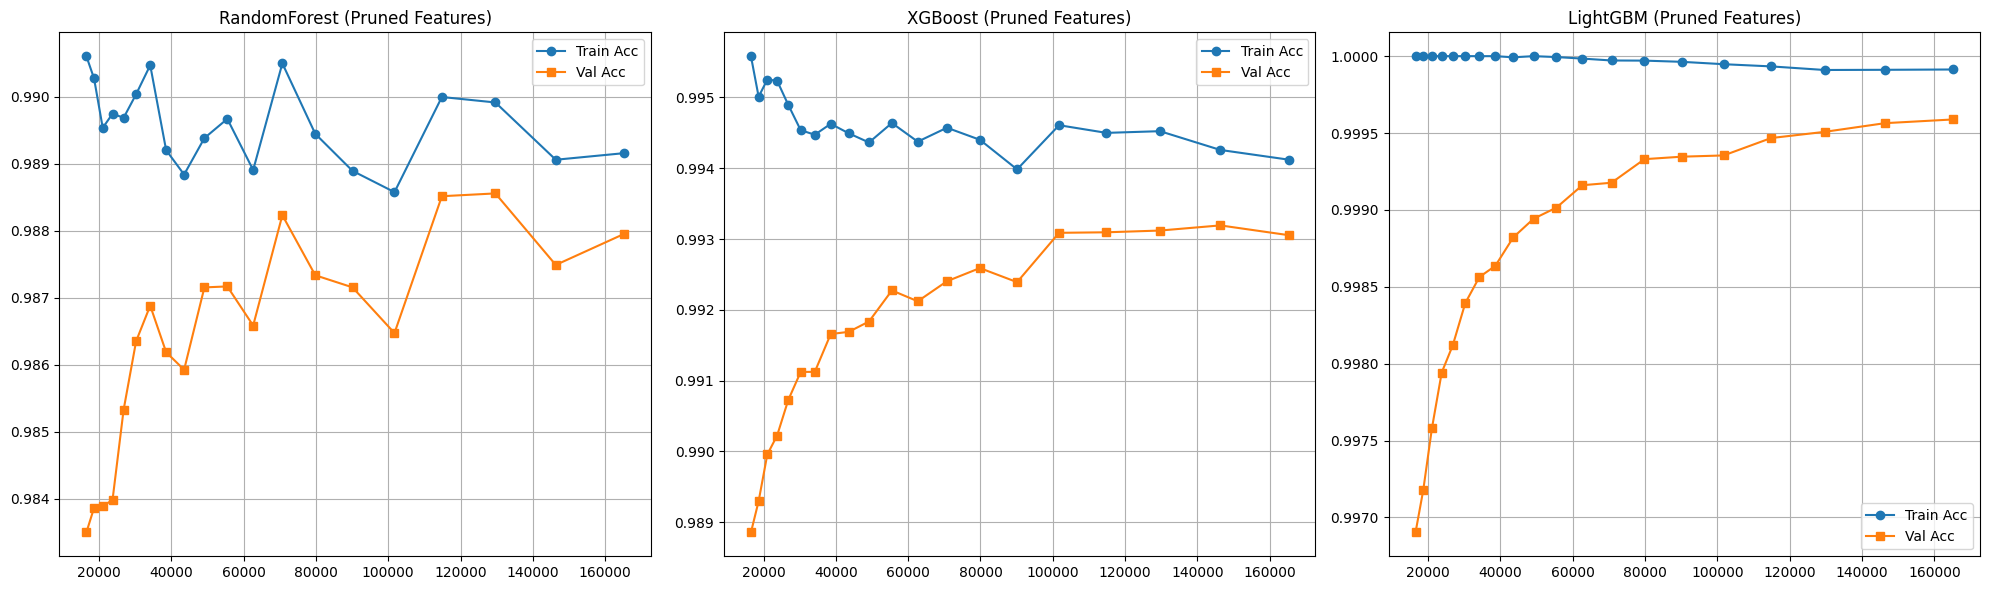

In [12]:
# 5. Generate Curves and Evaluate
plt.figure(figsize=(20, 6))
cv = StratifiedShuffleSplit(n_splits=3, test_size=0.2, random_state=42)

for i, (name, model) in enumerate(models.items()):
    print(f"Running {name}...")
    
    # Learning Curve
    train_sizes, train_scores, test_scores = learning_curve(
        model, X_res, y_res, cv=cv, n_jobs=-1, train_sizes=np.geomspace(0.1, 1.0, 20),scoring='f1_macro' 
    )
    
    plt.subplot(1, 3, i+1)
    plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', label="Train Acc")
    plt.plot(train_sizes, np.mean(test_scores, axis=1), 's-', label="Val Acc")
    plt.title(f"{name} (Pruned Features)")
    plt.legend()
    plt.grid()
    
    
    # Final Accuracy on the hold-out validation slice
    model.fit(X_res, y_res)
    y_pred = model.predict(X_val)
    print(f"\n{name} Results:")
    print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")


plt.tight_layout()
plt.show()
